In [ ]:
from google.colab import files

uploaded = files.upload()

Saving DDICorpus-2013.zip to DDICorpus-2013.zip


In [ ]:
import zipfile

zip_path = next(iter(uploaded))

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("DDI_Data")

print("Extraction completed!")

Extraction completed!


In [ ]:
import glob

xml_files = glob.glob(
    "DDI_Data/**/*.xml",
    recursive=True
)

print("Number of XML files:", len(xml_files))
print(xml_files[:5])

Number of XML files: 1017
['DDI_Data/DDICorpus/Test/Test for DrugNER task/DrugBank/Panitumumab.xml', 'DDI_Data/DDICorpus/Test/Test for DrugNER task/DrugBank/Porfimer.xml', 'DDI_Data/DDICorpus/Test/Test for DrugNER task/DrugBank/Milrinone.xml', 'DDI_Data/DDICorpus/Test/Test for DrugNER task/DrugBank/Pyrazinamide.xml', 'DDI_Data/DDICorpus/Test/Test for DrugNER task/DrugBank/Sulfanilamide.xml']


In [ ]:
import pandas as pd
import numpy as np
import xml.etree.ElementTree as ET
from tqdm import tqdm

In [ ]:
data = []

for file in tqdm(xml_files):

    tree = ET.parse(file)

    root = tree.getroot()

    for sentence in root.findall("sentence"):

        sentence_text = sentence.attrib["text"]

        entities = {}

        for entity in sentence.findall("entity"):

            entities[entity.attrib["id"]] = entity.attrib["text"]

        for pair in sentence.findall("pair"):

            if pair.attrib.get("ddi") == "true":

                e1 = pair.attrib["e1"]
                e2 = pair.attrib["e2"]

                drug1 = entities.get(e1)
                drug2 = entities.get(e2)

                ddi_type = pair.attrib.get("type")

                data.append([
                    sentence_text,
                    drug1,
                    drug2,
                    ddi_type
                ])

100%|██████████| 1017/1017 [00:00<00:00, 2796.88it/s]


In [ ]:
df = pd.DataFrame(
    data,
    columns=[
        "sentence",
        "drug1",
        "drug2",
        "label"
    ]
)

df.head()

,sentence,drug1,drug2,label
0,Mutual inhibition of metabolism occurs with co...,cyclosporin,methylprednisolone,mechanism
1,convulsions have been reported with concurrent...,methylprednisolone,cyclosporin,effect
2,Drugs that induce hepatic enzymes such as phen...,phenobarbital,methylprednisolone,mechanism
3,Drugs that induce hepatic enzymes such as phen...,phenobarbital,methylprednisolone,advise
4,Drugs that induce hepatic enzymes such as phen...,phenytoin,methylprednisolone,mechanism


In [ ]:
print(df.shape)

(5000, 4)


In [ ]:
df["label"].value_counts()

,count
label,
effect,2047
mechanism,1621
advise,1047
int,284


In [ ]:
df.isnull().sum()

,0
sentence,0
drug1,0
drug2,0
label,1


In [ ]:
df = df.dropna()

print(df.shape)

(4999, 4)


In [ ]:
print(df["label"].unique())

['mechanism' 'effect' 'advise' 'int']


In [ ]:
df.to_csv(
    "ddi_raw_parsed.csv",
    index=False
)

print("Saved!")

Saved!


In [ ]:
def mask_drugs(row):

    text = row["sentence"]

    drug1 = str(row["drug1"])
    drug2 = str(row["drug2"])

    text = text.replace(drug1, "DRUG1", 1)
    text = text.replace(drug2, "DRUG2", 1)

    return text

In [ ]:
df["masked_text"] = df.apply(
    mask_drugs,
    axis=1
)

df[["sentence", "masked_text"]].head()

,sentence,masked_text
0,Mutual inhibition of metabolism occurs with co...,Mutual inhibition of metabolism occurs with co...
1,convulsions have been reported with concurrent...,convulsions have been reported with concurrent...
2,Drugs that induce hepatic enzymes such as phen...,Drugs that induce hepatic enzymes such as DRUG...
3,Drugs that induce hepatic enzymes such as phen...,Drugs that induce hepatic enzymes such as DRUG...
4,Drugs that induce hepatic enzymes such as phen...,Drugs that induce hepatic enzymes such as phen...


In [ ]:
for i in range(5):

    print("ORIGINAL:")
    print(df["sentence"].iloc[i])

    print("\nMASKED:")
    print(df["masked_text"].iloc[i])

    print("\n" + "="*100 + "\n")

ORIGINAL:
Mutual inhibition of metabolism occurs with concurrent use of cyclosporin and methylprednisolone; 

MASKED:
Mutual inhibition of metabolism occurs with concurrent use of DRUG1 and DRUG2; 


ORIGINAL:
convulsions have been reported with concurrent use of methylprednisolone and cyclosporin. 

MASKED:
convulsions have been reported with concurrent use of DRUG1 and DRUG2. 


ORIGINAL:
Drugs that induce hepatic enzymes such as phenobarbital, phenytoin, and rifampin may increase the clearance of methylprednisolone and may require increased in methylprednisolone dose to achieve the desired response. 

MASKED:
Drugs that induce hepatic enzymes such as DRUG1, phenytoin, and rifampin may increase the clearance of DRUG2 and may require increased in methylprednisolone dose to achieve the desired response. 


ORIGINAL:
Drugs that induce hepatic enzymes such as phenobarbital, phenytoin, and rifampin may increase the clearance of methylprednisolone and may require increased in methylprednis

In [ ]:
import re

In [ ]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [ ]:
df["clean_text"] = df["masked_text"].apply(
    clean_text
)

df["clean_text"].head()

,clean_text
0,mutual inhibition of metabolism occurs with co...
1,convulsions have been reported with concurrent...
2,drugs that induce hepatic enzymes such as drug...
3,drugs that induce hepatic enzymes such as drug...
4,drugs that induce hepatic enzymes such as phen...


In [ ]:
import nltk

nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

In [ ]:
def lemmatize_text(text):

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]

    return " ".join(words)

In [ ]:
df["lemmatized_text"] = df["clean_text"].apply(
    lemmatize_text
)

df["lemmatized_text"].head()

,lemmatized_text
0,mutual inhibition of metabolism occurs with co...
1,convulsion have been reported with concurrent ...
2,drug that induce hepatic enzyme such a drug1 p...
3,drug that induce hepatic enzyme such a drug1 p...
4,drug that induce hepatic enzyme such a phenoba...


In [ ]:
for i in range(3):

    print("ORIGINAL:")
    print(df["sentence"].iloc[i])

    print("\nFINAL:")
    print(df["lemmatized_text"].iloc[i])

    print("\n" + "="*100 + "\n")

ORIGINAL:
Mutual inhibition of metabolism occurs with concurrent use of cyclosporin and methylprednisolone; 

FINAL:
mutual inhibition of metabolism occurs with concurrent use of drug1 and drug2


ORIGINAL:
convulsions have been reported with concurrent use of methylprednisolone and cyclosporin. 

FINAL:
convulsion have been reported with concurrent use of drug1 and drug2


ORIGINAL:
Drugs that induce hepatic enzymes such as phenobarbital, phenytoin, and rifampin may increase the clearance of methylprednisolone and may require increased in methylprednisolone dose to achieve the desired response. 

FINAL:
drug that induce hepatic enzyme such a drug1 phenytoin and rifampin may increase the clearance of drug2 and may require increased in methylprednisolone dose to achieve the desired response




In [ ]:
df.to_csv(
    "ddi_processed.csv",
    index=False
)

print("Processed dataset saved!")

Processed dataset saved!


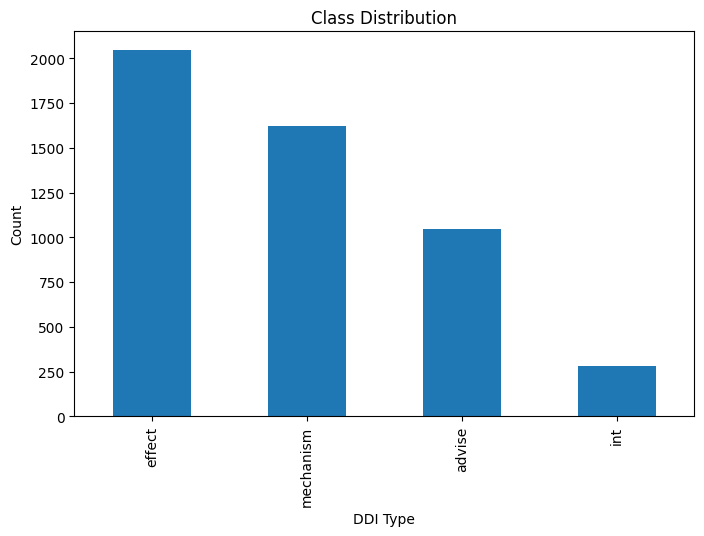

In [ ]:
import matplotlib.pyplot as plt

label_counts = df["label"].value_counts()

plt.figure(figsize=(8,5))

label_counts.plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("DDI Type")
plt.ylabel("Count")

plt.show()

In [ ]:
print(df["label"].value_counts())

label
effect       2047
mechanism    1621
advise       1047
int           284
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import MultinomialNB

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    accuracy_score
)

In [ ]:
X = df["lemmatized_text"]

y = df["label"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train Size:", len(X_train))
print("Test Size:", len(X_test))

Train Size: 3999
Test Size: 1000


In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)

(3999, 3780)


In [ ]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(
    X_train_tfidf,
    y_train
)

y_pred_lr = lr.predict(X_test_tfidf)

print(classification_report(
    y_test,
    y_pred_lr
))

              precision    recall  f1-score   support

      advise       0.94      0.91      0.92       209
      effect       0.93      0.94      0.93       410
         int       0.98      0.77      0.86        57
   mechanism       0.93      0.96      0.95       324

    accuracy                           0.93      1000
   macro avg       0.94      0.90      0.92      1000
weighted avg       0.93      0.93      0.93      1000



In [ ]:
lr_acc = accuracy_score(
    y_test,
    y_pred_lr
)

print("Accuracy:", lr_acc)

Accuracy: 0.932


In [ ]:
nb = MultinomialNB()

nb.fit(
    X_train_tfidf,
    y_train
)

y_pred_nb = nb.predict(
    X_test_tfidf
)

print(classification_report(
    y_test,
    y_pred_nb
))

              precision    recall  f1-score   support

      advise       0.92      0.79      0.85       209
      effect       0.85      0.93      0.89       410
         int       1.00      0.46      0.63        57
   mechanism       0.87      0.94      0.90       324

    accuracy                           0.88      1000
   macro avg       0.91      0.78      0.82      1000
weighted avg       0.88      0.88      0.87      1000



In [ ]:
nb_acc = accuracy_score(
    y_test,
    y_pred_nb
)

print("Accuracy:", nb_acc)

Accuracy: 0.876


In [ ]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(
    X_train_tfidf,
    y_train
)

y_pred_dt = dt.predict(
    X_test_tfidf
)

print(classification_report(
    y_test,
    y_pred_dt
))

              precision    recall  f1-score   support

      advise       0.90      0.92      0.91       209
      effect       0.93      0.92      0.92       410
         int       0.89      0.89      0.89        57
   mechanism       0.94      0.94      0.94       324

    accuracy                           0.93      1000
   macro avg       0.92      0.92      0.92      1000
weighted avg       0.93      0.93      0.93      1000



In [ ]:
dt_acc = accuracy_score(
    y_test,
    y_pred_dt
)

print("Accuracy:", dt_acc)

Accuracy: 0.925


In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train_tfidf,
    y_train
)

y_pred_rf = rf.predict(
    X_test_tfidf
)

print(classification_report(
    y_test,
    y_pred_rf
))

              precision    recall  f1-score   support

      advise       0.95      0.91      0.93       209
      effect       0.93      0.93      0.93       410
         int       0.91      0.86      0.88        57
   mechanism       0.94      0.97      0.95       324

    accuracy                           0.94      1000
   macro avg       0.93      0.92      0.92      1000
weighted avg       0.94      0.94      0.94      1000



In [ ]:
rf_acc = accuracy_score(
    y_test,
    y_pred_rf
)

print("Accuracy:", rf_acc)

Accuracy: 0.936


In [ ]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        lr_acc,
        nb_acc,
        dt_acc,
        rf_acc
    ]
})

comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
)

comparison_df

,Model,Accuracy
3,Random Forest,0.936
0,Logistic Regression,0.932
2,Decision Tree,0.925
1,Naive Bayes,0.876


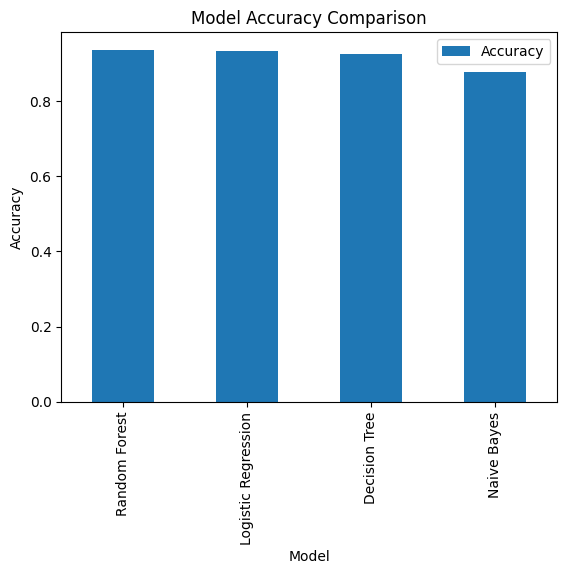

In [ ]:
import matplotlib.pyplot as plt

comparison_df.plot(
    x="Model",
    y="Accuracy",
    kind="bar"
)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred_rf
)

cm

array([[191,  13,   0,   5],
       [  9, 383,   5,  13],
       [  0,   7,  49,   1],
       [  2,   9,   0, 313]])

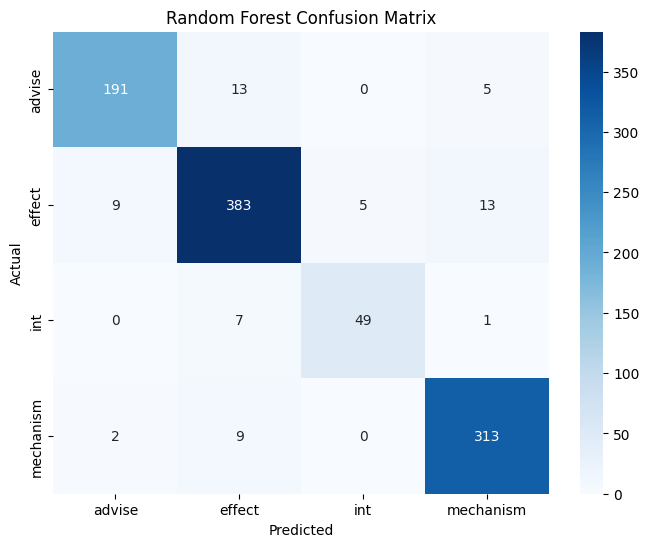

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=rf.classes_,
    yticklabels=rf.classes_
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Random Forest Confusion Matrix")

plt.show()

In [ ]:
feature_names = tfidf.get_feature_names_out()

importances = rf.feature_importances_

feature_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_df = feature_df.sort_values(
    by="Importance",
    ascending=False
)

feature_df.head(20)

,Feature,Importance
3166,should,0.045902
595,be,0.028838
1311,effect,0.022591
2722,plasma,0.020744
207,absorption,0.017286
920,concentration,0.017211
2244,metabolism,0.016729
2497,not,0.014670
2098,level,0.014184
753,caution,0.012873


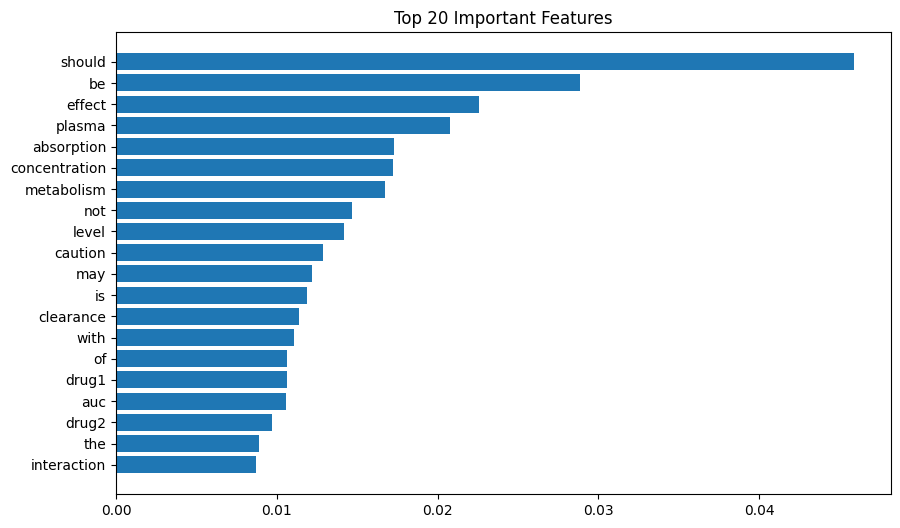

In [ ]:
top20 = feature_df.head(20)

plt.figure(figsize=(10,6))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.title("Top 20 Important Features")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
import pickle

with open(
    "tfidf.pkl",
    "wb"
) as f:

    pickle.dump(
        tfidf,
        f
    )

print("TF-IDF saved")

TF-IDF saved


In [ ]:
with open(
    "rf_model.pkl",
    "wb"
) as f:

    pickle.dump(
        rf,
        f
    )

print("Random Forest saved")

Random Forest saved


In [ ]:
from google.colab import files

files.download("rf_model.pkl")

files.download("tfidf.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
def predict_ddi(text):

    text = clean_text(text)

    text = lemmatize_text(text)

    vector = tfidf.transform(
        [text]
    )

    prediction = rf.predict(
        vector
    )

    return prediction[0]

In [ ]:
predict_ddi(
    "drug1 should not be administered with drug2"
)

'advise'

In [ ]:
predict_ddi(
    "drug1 increases the toxicity of drug2"
)

'mechanism'